In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import glob
import os
from collections import Counter
import warnings

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

# Large-scale extraction on bioRxiv

Summary statistics for marker gene extractions from 504 bioRxiv preprints.

## Load data

In [2]:
MECA_DIR = "../data/biorxiv/meca"

records = []
all_markers = []
for folder in sorted(os.listdir(MECA_DIR)):
    fpath = os.path.join(MECA_DIR, folder)
    if not os.path.isdir(fpath):
        continue

    markers_path = os.path.join(fpath, "markers.json")
    metrics_path = os.path.join(fpath, "metrics.json")
    ms_path = os.path.join(fpath, "manuscript.md")

    markers = []
    if os.path.exists(markers_path):
        with open(markers_path) as f:
            markers = json.load(f)

    metrics = {}
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            metrics = json.load(f)

    ms_chars = 0
    if os.path.exists(ms_path):
        ms_chars = os.path.getsize(ms_path)

    for m in markers:
        m["_paper_id"] = folder
    all_markers.extend(markers)

    records.append({
        "paper_id": folder,
        "n_extractions": len(markers),
        "ms_chars": ms_chars,
        "input_tokens": metrics.get("input_tokens", 0),
        "output_tokens": metrics.get("output_tokens", 0),
        "total_cost": metrics.get("total_cost", 0),
        "processing_time_sec": metrics.get("processing_time_sec", 0),
    })

papers = pd.DataFrame(records)
markers_df = pd.DataFrame(all_markers)

print(f"Total papers: {len(papers)}")
print(f"Papers with extractions: {(papers['n_extractions'] > 0).sum()}")
print(f"Papers with 0 extractions: {(papers['n_extractions'] == 0).sum()}")
print(f"Total marker-gene associations: {len(markers_df):,}")

Total papers: 504
Papers with extractions: 421
Papers with 0 extractions: 83
Total marker-gene associations: 12,501


## Paper-level statistics

In [3]:
has_markers = papers[papers["n_extractions"] > 0].copy()

print("Extractions per paper (papers with markers):")
print(f"  Mean:   {has_markers['n_extractions'].mean():.1f}")
print(f"  Median: {has_markers['n_extractions'].median():.0f}")
print(f"  Std:    {has_markers['n_extractions'].std():.1f}")
print(f"  Min:    {has_markers['n_extractions'].min()}")
print(f"  Max:    {has_markers['n_extractions'].max()}")
print()
print("Manuscript size (all papers):")
print(f"  Mean:   {papers['ms_chars'].mean()/1000:.1f}k chars")
print(f"  Median: {papers['ms_chars'].median()/1000:.1f}k chars")

Extractions per paper (papers with markers):
  Mean:   29.7
  Median: 19
  Std:    30.6
  Min:    1
  Max:    212

Manuscript size (all papers):
  Mean:   48.2k chars
  Median: 46.1k chars


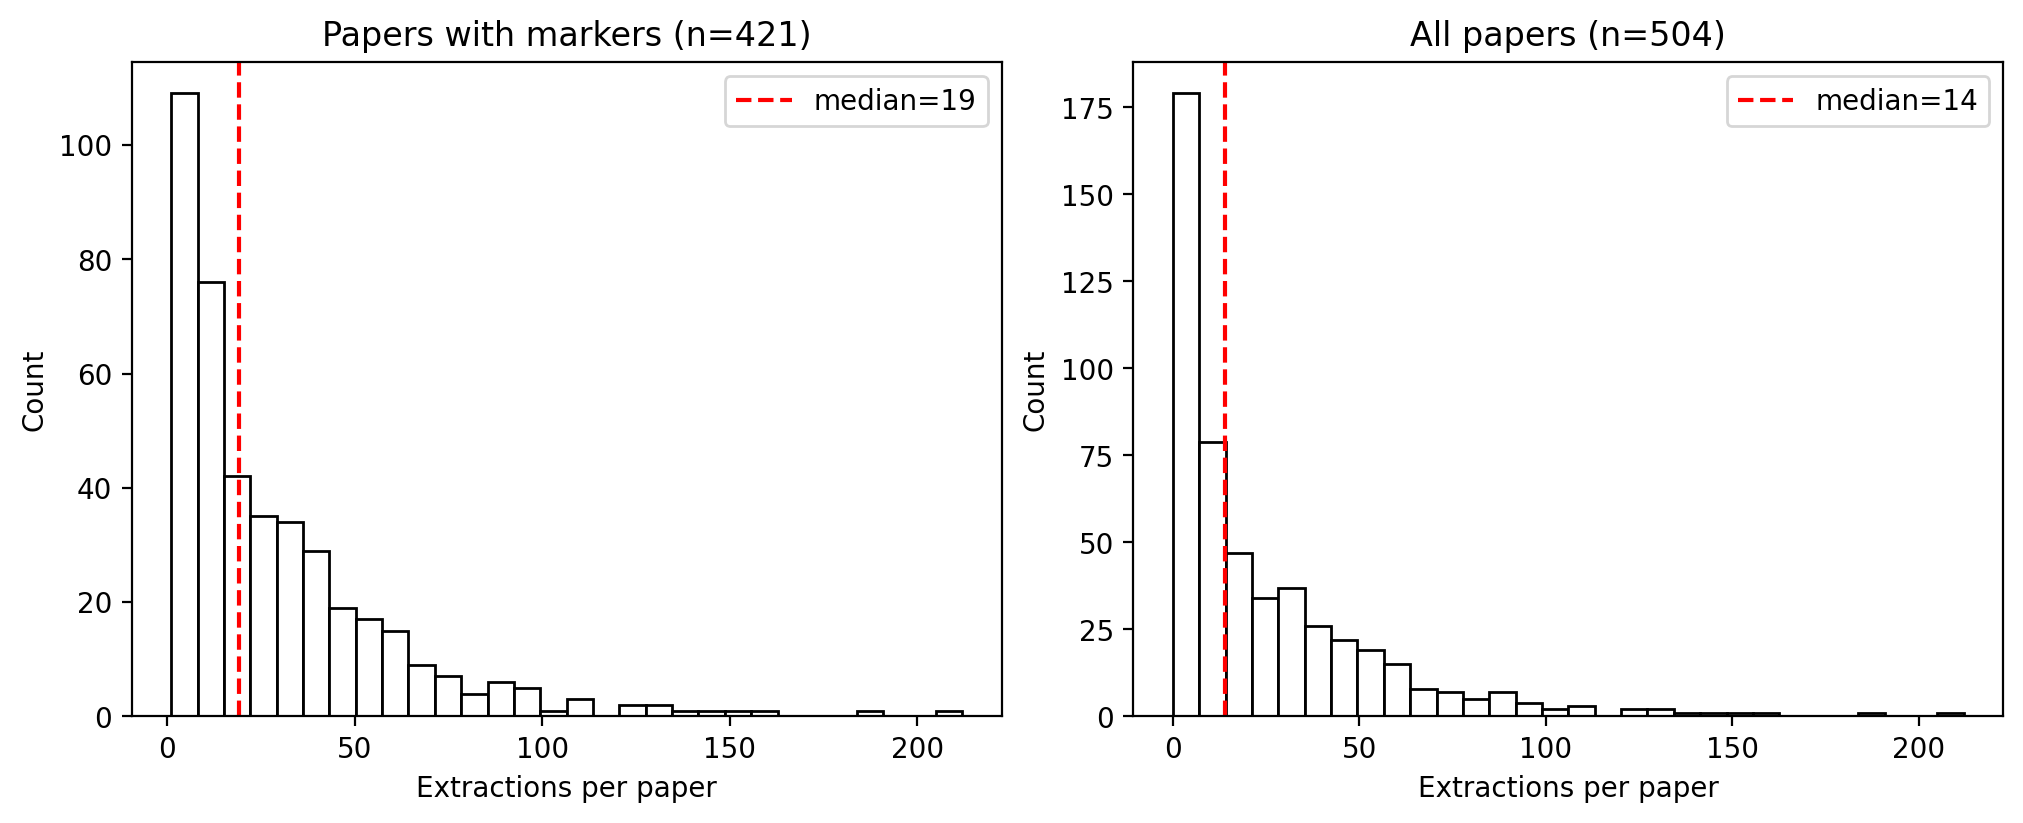

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Extractions per paper
ax = axes[0]
vals = has_markers["n_extractions"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.0f}")
ax.set(xlabel="Extractions per paper", ylabel="Count",
       title=f"Papers with markers (n={len(has_markers)})")
ax.legend()

# All papers including zeros
ax = axes[1]
vals = papers["n_extractions"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.0f}")
ax.set(xlabel="Extractions per paper", ylabel="Count",
       title=f"All papers (n={len(papers)})")
ax.legend()

plt.show()

## Organisms

In [5]:
org_counts = markers_df["organism"].value_counts()
org_df = org_counts.reset_index()
org_df.columns = ["organism", "count"]
org_df["pct"] = org_df["count"] / org_df["count"].sum() * 100
org_df

,organism,count,pct
0,homo_sapiens,8921,71.362291
1,mus_musculus,2417,19.334453
2,sus_scrofa,517,4.135669
3,danio_rerio,139,1.111911
4,macaca_mulatta,112,0.895928
5,callithrix_jacchus,95,0.759939
6,rattus_norvegicus,68,0.543956
7,trypanosoma_brucei,55,0.439965
8,aedes_aegypti,42,0.335973
9,penaeus_vannamei,38,0.303976


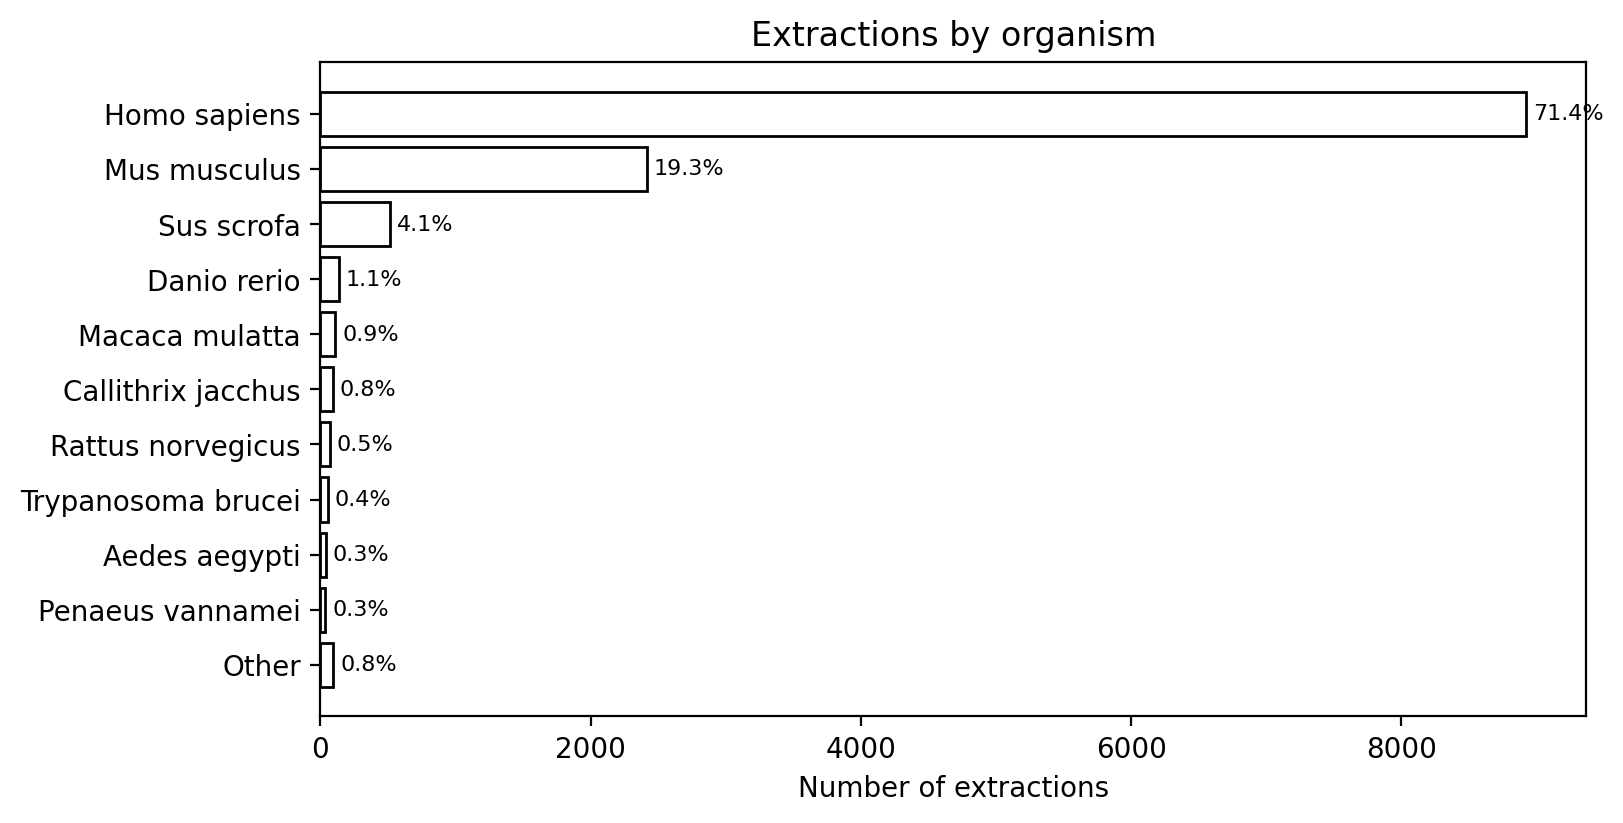

In [6]:
# Top organisms bar chart
top_n = 10
top_orgs = org_df.head(top_n).copy()
if len(org_df) > top_n:
    other = org_df.iloc[top_n:]["count"].sum()
    other_pct = org_df.iloc[top_n:]["pct"].sum()
    top_orgs = pd.concat([top_orgs, pd.DataFrame([{"organism": "other", "count": other, "pct": other_pct}])],
                         ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
bars = ax.barh(range(len(top_orgs)), top_orgs["count"], edgecolor="k", facecolor="white")
ax.set_yticks(range(len(top_orgs)))
ax.set_yticklabels([o.replace("_", " ").capitalize() for o in top_orgs["organism"]])
ax.invert_yaxis()
ax.set(xlabel="Number of extractions", title="Extractions by organism")

for i, (c, p) in enumerate(zip(top_orgs["count"], top_orgs["pct"])):
    ax.text(c + 50, i, f"{p:.1f}%", va="center", fontsize=8)

plt.show()

## Genes and cell types

In [7]:
markers_df["group_name_upper"] = markers_df["group_name"].str.strip().str.upper()
markers_df["feature_name_upper"] = markers_df["feature_name"].str.strip().str.upper()

n_unique_genes = markers_df["feature_name_upper"].nunique()
n_unique_celltypes = markers_df["group_name_upper"].nunique()
n_unique_pairs = markers_df.groupby(["group_name_upper", "feature_name_upper"]).ngroups

print(f"Unique genes:      {n_unique_genes:,}")
print(f"Unique cell types: {n_unique_celltypes:,}")
print(f"Unique (cell type, gene) pairs: {n_unique_pairs:,}")

Unique genes:      3,906
Unique cell types: 2,720
Unique (cell type, gene) pairs: 11,231


In [8]:
# Per-paper unique genes and cell types
paper_stats = []
for pid, grp in markers_df.groupby("_paper_id"):
    paper_stats.append({
        "paper_id": pid,
        "n_genes": grp["feature_name_upper"].nunique(),
        "n_celltypes": grp["group_name_upper"].nunique(),
        "n_records": len(grp),
    })
paper_stats = pd.DataFrame(paper_stats)

print("Per paper (papers with markers):")
print(f"  Genes:      mean={paper_stats['n_genes'].mean():.1f}, median={paper_stats['n_genes'].median():.0f}")
print(f"  Cell types: mean={paper_stats['n_celltypes'].mean():.1f}, median={paper_stats['n_celltypes'].median():.0f}")

Per paper (papers with markers):
  Genes:      mean=21.8, median=14
  Cell types: mean=8.9, median=7


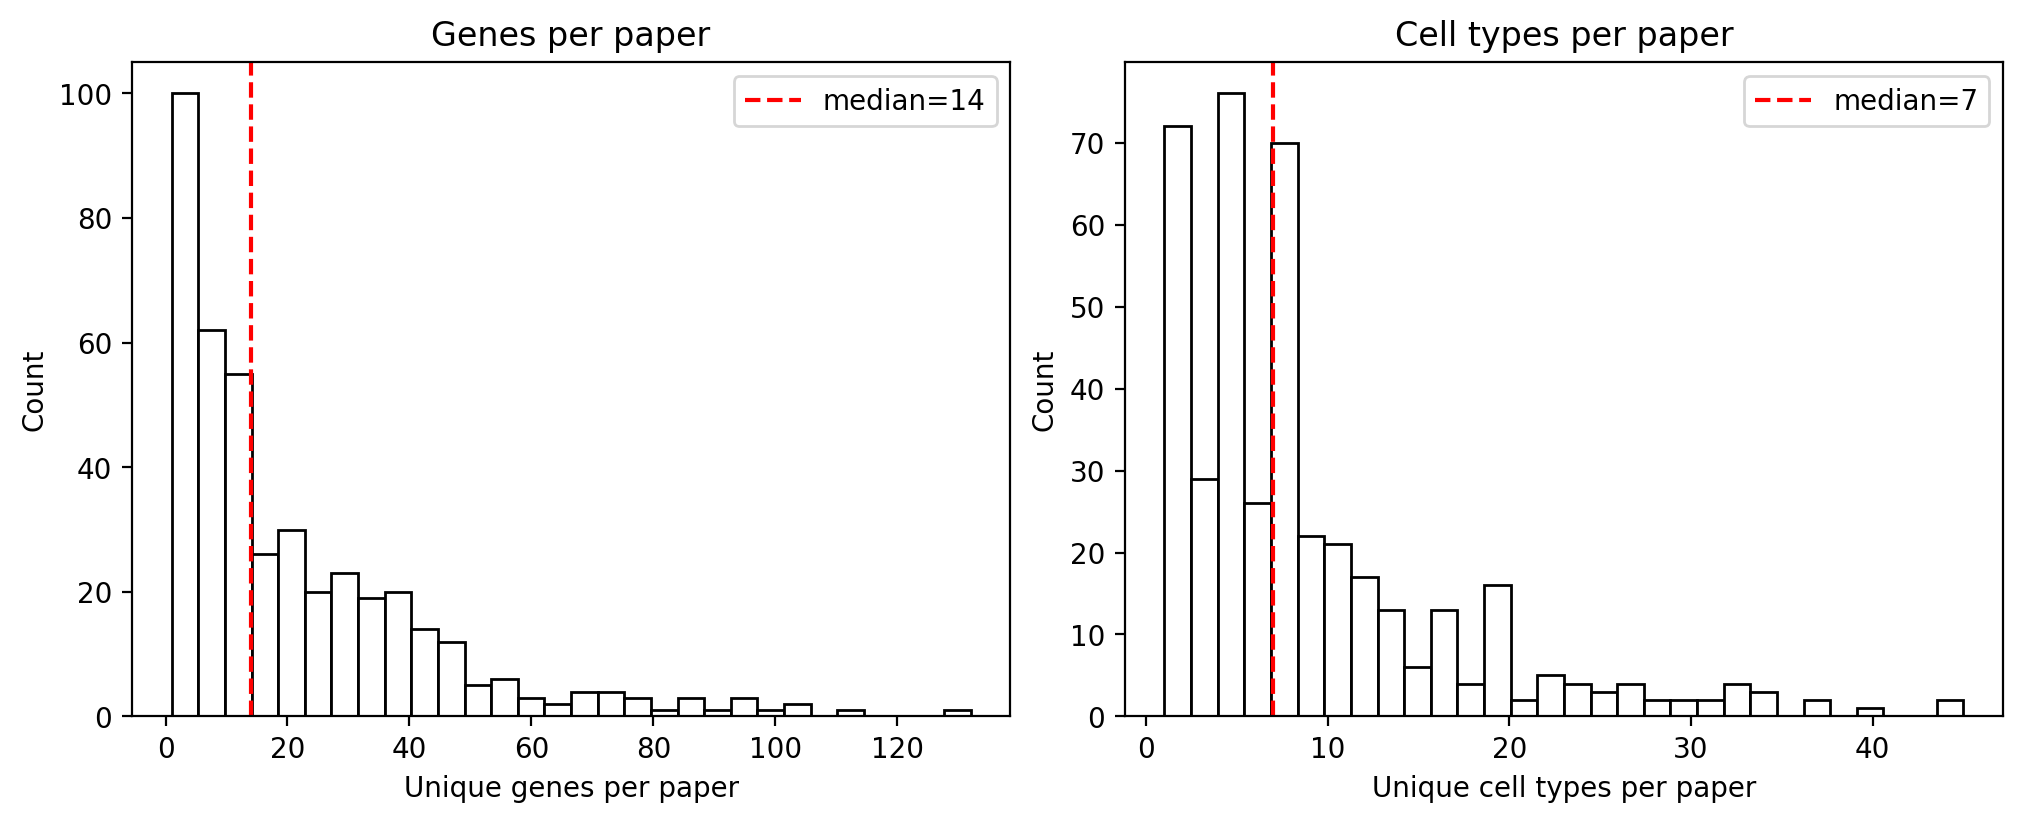

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
vals = paper_stats["n_genes"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.0f}")
ax.set(xlabel="Unique genes per paper", ylabel="Count", title="Genes per paper")
ax.legend()

ax = axes[1]
vals = paper_stats["n_celltypes"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.0f}")
ax.set(xlabel="Unique cell types per paper", ylabel="Count", title="Cell types per paper")
ax.legend()

plt.show()

In [10]:
# Most common genes across all papers
gene_counts = markers_df["feature_name_upper"].value_counts()
print("Top 20 most extracted genes:")
for gene, count in gene_counts.head(20).items():
    n_papers = markers_df[markers_df["feature_name_upper"] == gene]["_paper_id"].nunique()
    print(f"  {gene:<15} {count:>4} extractions across {n_papers:>3} papers")

Top 20 most extracted genes:
  MKI67             64 extractions across  40 papers
  CD4               64 extractions across  43 papers
  CCR7              57 extractions across  33 papers
  SOX2              54 extractions across  31 papers
  CD14              53 extractions across  40 papers


  CD44              49 extractions across  28 papers
  NKG7              49 extractions across  31 papers
  ACTA2             47 extractions across  29 papers
  APOE              45 extractions across  28 papers
  CD8A              43 extractions across  32 papers
  COL1A1            42 extractions across  27 papers
  S100A8            42 extractions across  30 papers
  PRF1              41 extractions across  24 papers
  CD19              40 extractions across  24 papers
  IL7R              39 extractions across  26 papers
  GZMA              39 extractions across  23 papers
  TOP2A             39 extractions across  27 papers
  CD3D              39 extractions across  28 papers
  GZMK              38 extractions across  24 papers
  GZMB              38 extractions across  23 papers


In [11]:
# Most common cell types
ct_counts = markers_df["group_name_upper"].value_counts()
print("Top 20 most common cell types:")
for ct, count in ct_counts.head(20).items():
    n_papers = markers_df[markers_df["group_name_upper"] == ct]["_paper_id"].nunique()
    print(f"  {ct:<35} {count:>4} extractions across {n_papers:>3} papers")

Top 20 most common cell types:
  MICROGLIA                            131 extractions across  20 papers
  T CELL                               122 extractions across  33 papers
  NK CELL                              120 extractions across  30 papers
  EPI                                  114 extractions across   4 papers
  B CELL                               101 extractions across  43 papers
  MONOCYTE                             100 extractions across  34 papers
  PRE                                   98 extractions across   2 papers
  ENDOTHELIAL CELL                      84 extractions across  35 papers
  CD4+ T CELL                           81 extractions across  15 papers
  CD8+ T CELL                           77 extractions across  13 papers
  MACROPHAGE                            73 extractions across  37 papers
  CLUSTER 2                             67 extractions across  15 papers
  FIBROBLAST                            65 extractions across  23 papers
  CLUSTER 3         

## Verification

In [12]:
has_verif = markers_df[markers_df["_verification"].notna()].copy()
n_total = len(has_verif)

if n_total > 0:
    v = has_verif["_verification"].apply(pd.Series)
    n_all = v["all_verified"].sum()
    n_sr = v["source_rationale_found"].sum()
    n_gl = v["group_label_found"].sum()
    n_fl = v["feature_label_found"].sum()

    print(f"Verification results (n={n_total:,}):")
    print(f"  source_rationale found: {n_sr:,} ({n_sr/n_total*100:.1f}%)")
    print(f"  group_label found:      {n_gl:,} ({n_gl/n_total*100:.1f}%)")
    print(f"  feature_label found:    {n_fl:,} ({n_fl/n_total*100:.1f}%)")
    print(f"  all verified:           {n_all:,} ({n_all/n_total*100:.1f}%)")
    print()
    print("Note: source_rationale is 100% because failed rationale matches are discarded.")
    print(f"group_label failures: {n_total - n_gl:,} ({(n_total - n_gl)/n_total*100:.1f}%)")
    print(f"feature_label failures: {n_total - n_fl:,} ({(n_total - n_fl)/n_total*100:.1f}%)")

Verification results (n=12,501):
  source_rationale found: 12,501 (100.0%)
  group_label found:      11,240 (89.9%)
  feature_label found:    12,375 (99.0%)
  all verified:           11,131 (89.0%)

Note: source_rationale is 100% because failed rationale matches are discarded.
group_label failures: 1,261 (10.1%)
feature_label failures: 126 (1.0%)


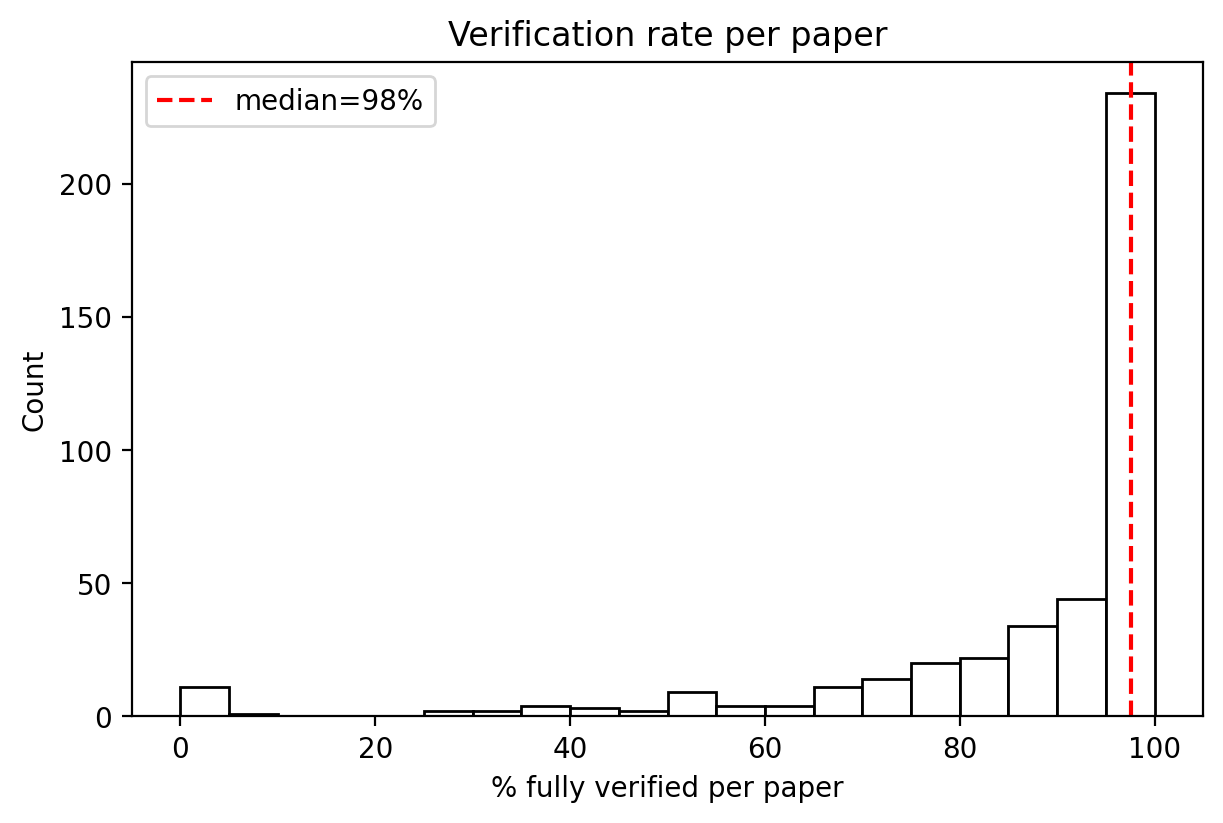


Papers with 100% verification: 202 / 421
Papers with <50% verification: 25 / 421


In [13]:
# Per-paper verification rate
if n_total > 0:
    paper_verif = has_verif.copy()
    paper_verif["all_verified"] = paper_verif["_verification"].apply(lambda x: x.get("all_verified", False))
    pv = paper_verif.groupby("_paper_id").agg(
        n_records=("all_verified", "count"),
        n_verified=("all_verified", "sum"),
    )
    pv["pct_verified"] = pv["n_verified"] / pv["n_records"] * 100

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.hist(pv["pct_verified"], bins=20, edgecolor="k", facecolor="white")
    ax.axvline(pv["pct_verified"].median(), color="red", ls="--",
               label=f"median={pv['pct_verified'].median():.0f}%")
    ax.set(xlabel="% fully verified per paper", ylabel="Count",
           title="Verification rate per paper")
    ax.legend()
    plt.show()

    print(f"\nPapers with 100% verification: {(pv['pct_verified'] == 100).sum()} / {len(pv)}")
    print(f"Papers with <50% verification: {(pv['pct_verified'] < 50).sum()} / {len(pv)}")

## Cost and performance

In [14]:
processed = papers[papers["total_cost"] > 0].copy()

print(f"Total cost:           ${papers['total_cost'].sum():.2f}")
print(f"Mean cost/paper:      ${processed['total_cost'].mean():.3f}")
print(f"Median cost/paper:    ${processed['total_cost'].median():.3f}")
print(f"Total input tokens:   {papers['input_tokens'].sum():,}")
print(f"Total output tokens:  {papers['output_tokens'].sum():,}")
print(f"Sequential time:      {papers['processing_time_sec'].sum()/60:.1f} min")
print(f"Mean time/paper:      {processed['processing_time_sec'].mean():.1f} sec")

Total cost:           $91.70
Mean cost/paper:      $0.183
Median cost/paper:    $0.125
Total input tokens:   6,587,407
Total output tokens:  2,350,671
Sequential time:      367.6 min
Mean time/paper:      43.9 sec


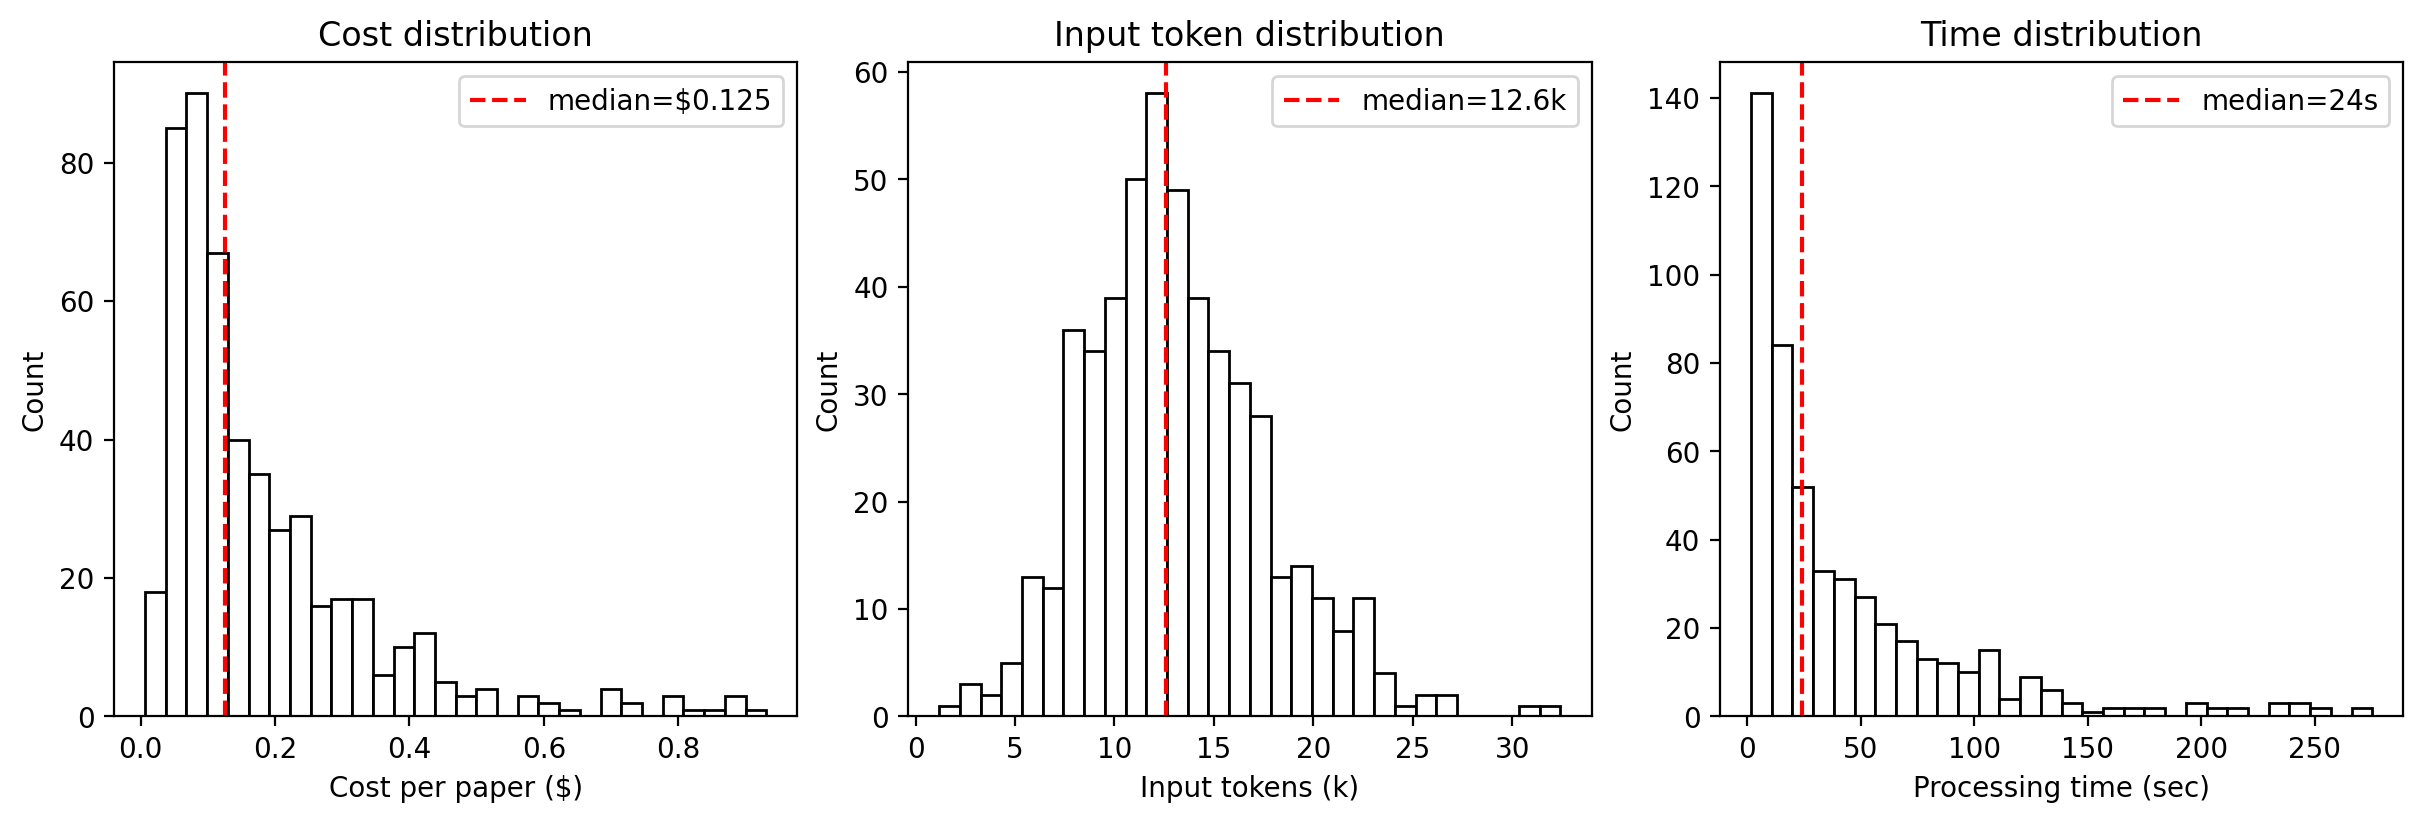

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
vals = processed["total_cost"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median=${vals.median():.3f}")
ax.set(xlabel="Cost per paper ($)", ylabel="Count", title="Cost distribution")
ax.legend()

ax = axes[1]
vals = processed["input_tokens"] / 1000
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.1f}k")
ax.set(xlabel="Input tokens (k)", ylabel="Count", title="Input token distribution")
ax.legend()

ax = axes[2]
vals = processed["processing_time_sec"]
ax.hist(vals, bins=30, edgecolor="k", facecolor="white")
ax.axvline(vals.median(), color="red", ls="--", label=f"median={vals.median():.0f}s")
ax.set(xlabel="Processing time (sec)", ylabel="Count", title="Time distribution")
ax.legend()

plt.show()

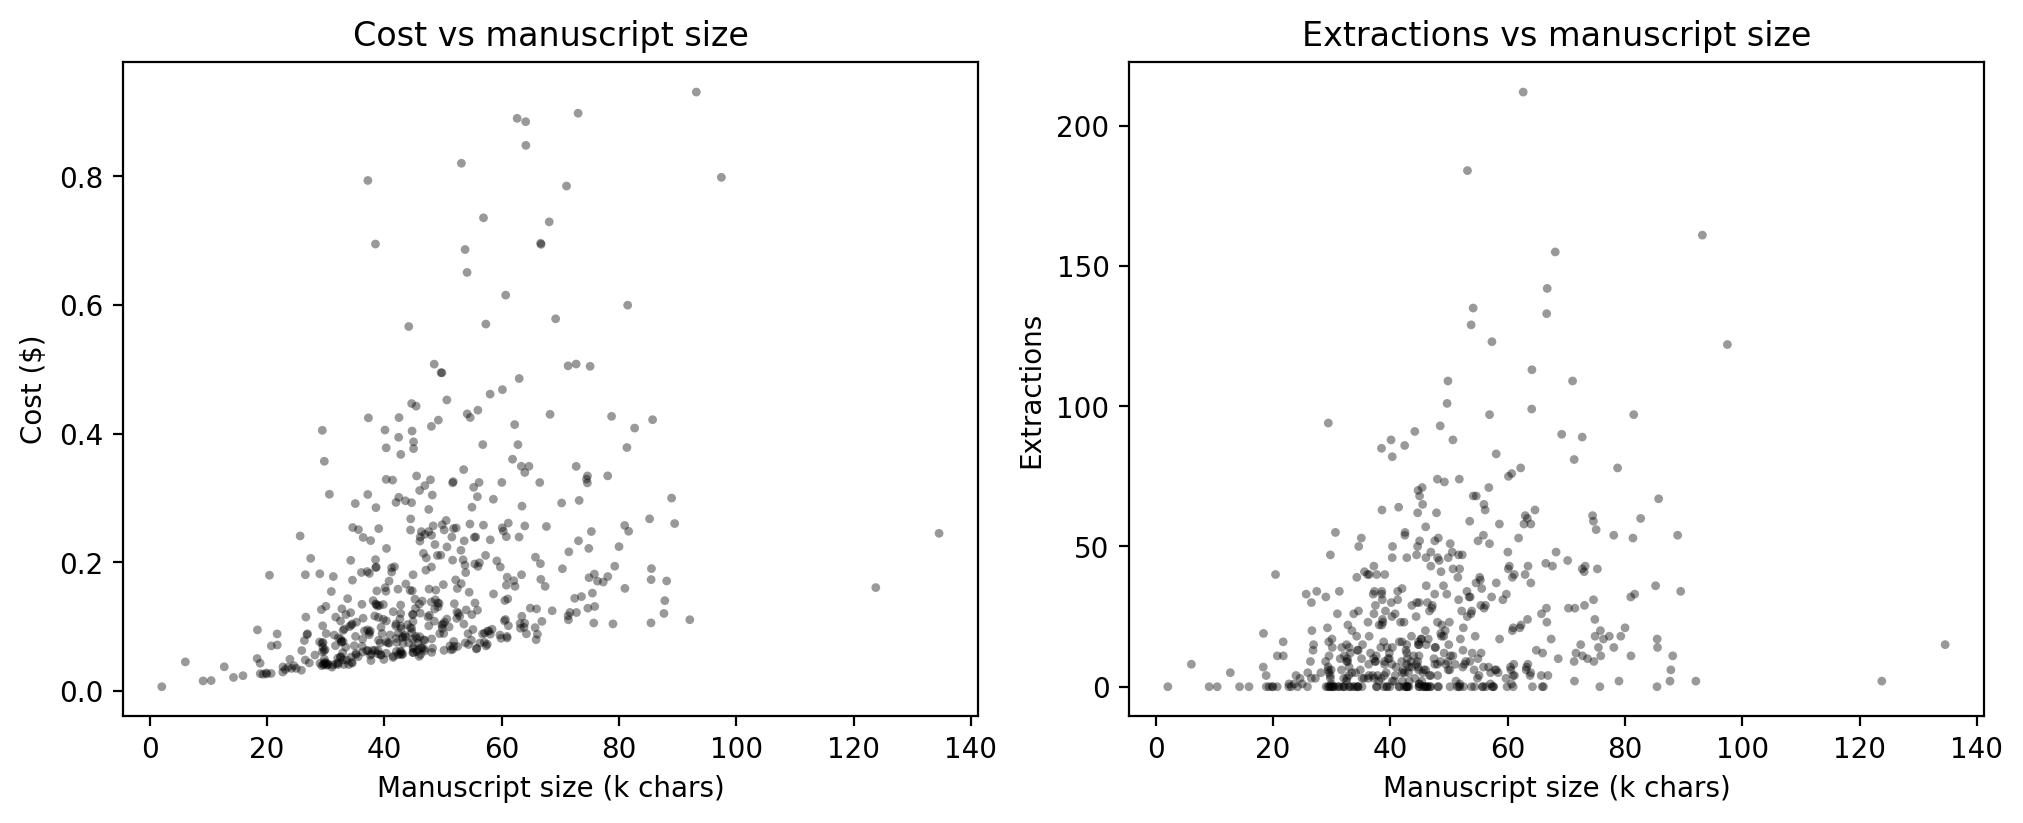

In [16]:
# Cost vs manuscript size
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

ax = axes[0]
ax.scatter(processed["ms_chars"] / 1000, processed["total_cost"],
           s=10, alpha=0.4, edgecolor="none", color="k")
ax.set(xlabel="Manuscript size (k chars)", ylabel="Cost ($)",
       title="Cost vs manuscript size")

ax = axes[1]
ax.scatter(processed["ms_chars"] / 1000, processed["n_extractions"],
           s=10, alpha=0.4, edgecolor="none", color="k")
ax.set(xlabel="Manuscript size (k chars)", ylabel="Extractions",
       title="Extractions vs manuscript size")

plt.show()

## Cross-paper gene overlap

Genes appearing in 1 paper only:  2488 (63.7%)
Genes appearing in 2-5 papers:    1094
Genes appearing in 6-10 papers:   202
Genes appearing in 11-50 papers:  122
Genes appearing in 50+ papers:    0


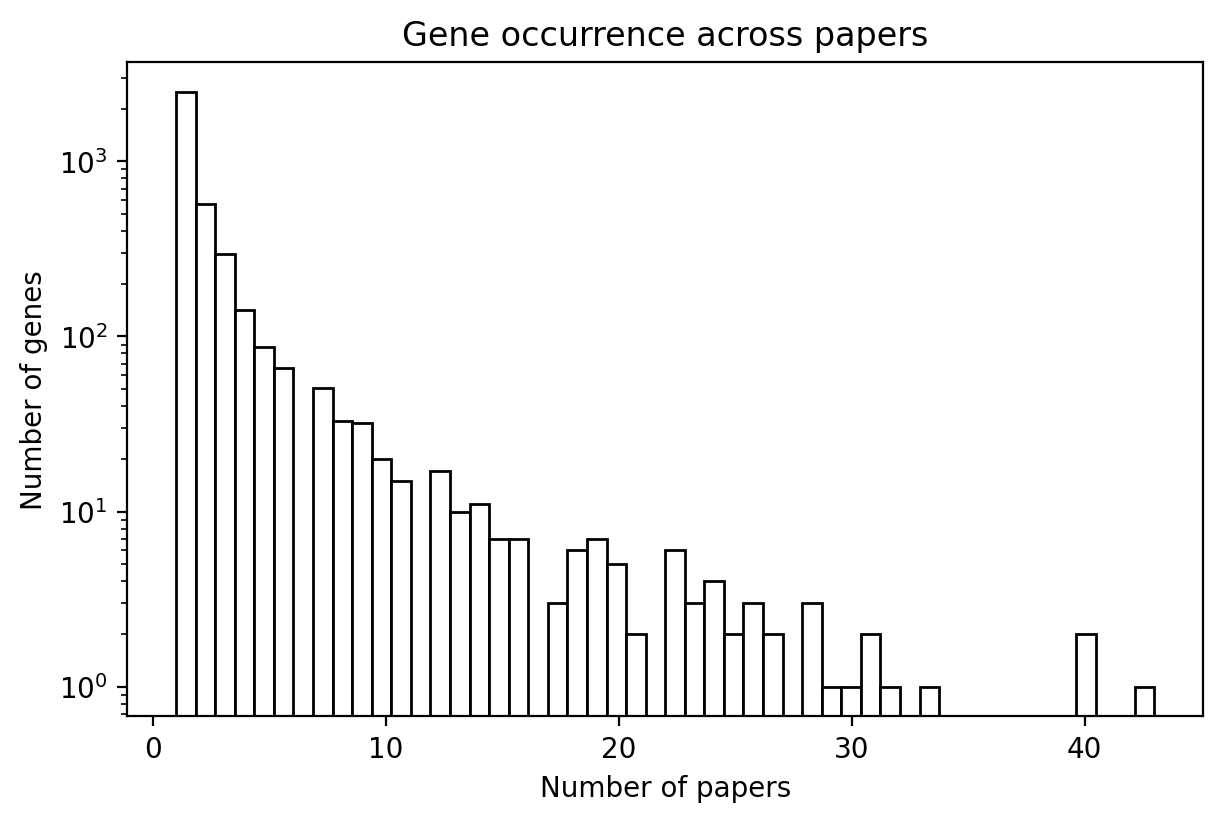

In [17]:
# How many papers does each gene appear in?
gene_paper_counts = markers_df.groupby("feature_name_upper")["_paper_id"].nunique()

print(f"Genes appearing in 1 paper only:  {(gene_paper_counts == 1).sum()} ({(gene_paper_counts == 1).mean()*100:.1f}%)")
print(f"Genes appearing in 2-5 papers:    {((gene_paper_counts >= 2) & (gene_paper_counts <= 5)).sum()}")
print(f"Genes appearing in 6-10 papers:   {((gene_paper_counts >= 6) & (gene_paper_counts <= 10)).sum()}")
print(f"Genes appearing in 11-50 papers:  {((gene_paper_counts >= 11) & (gene_paper_counts <= 50)).sum()}")
print(f"Genes appearing in 50+ papers:    {(gene_paper_counts > 50).sum()}")

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(gene_paper_counts.values, bins=50, edgecolor="k", facecolor="white")
ax.set(xlabel="Number of papers", ylabel="Number of genes",
       title="Gene occurrence across papers")
ax.set_yscale("log")
plt.show()

Cell types in 1 paper only:  2425 (89.2%)
Cell types in 2-5 papers:    244
Cell types in 6-10 papers:   30
Cell types in 11-50 papers:  21
Cell types in 50+ papers:    0


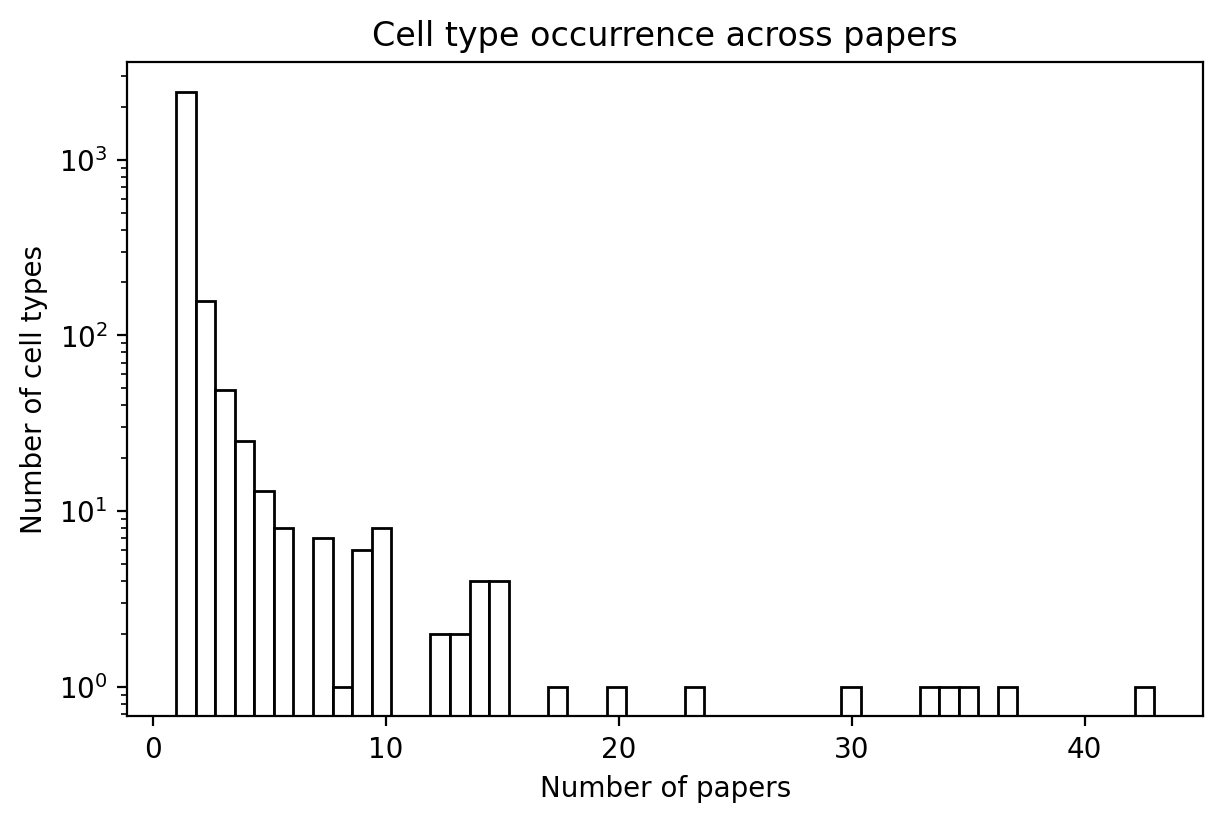

In [18]:
# Same for cell types
ct_paper_counts = markers_df.groupby("group_name_upper")["_paper_id"].nunique()

print(f"Cell types in 1 paper only:  {(ct_paper_counts == 1).sum()} ({(ct_paper_counts == 1).mean()*100:.1f}%)")
print(f"Cell types in 2-5 papers:    {((ct_paper_counts >= 2) & (ct_paper_counts <= 5)).sum()}")
print(f"Cell types in 6-10 papers:   {((ct_paper_counts >= 6) & (ct_paper_counts <= 10)).sum()}")
print(f"Cell types in 11-50 papers:  {((ct_paper_counts >= 11) & (ct_paper_counts <= 50)).sum()}")
print(f"Cell types in 50+ papers:    {(ct_paper_counts > 50).sum()}")

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(ct_paper_counts.values, bins=50, edgecolor="k", facecolor="white")
ax.set(xlabel="Number of papers", ylabel="Number of cell types",
       title="Cell type occurrence across papers")
ax.set_yscale("log")
plt.show()

## Summary table

In [19]:
summary = {
    "Papers processed": len(papers),
    "Papers with markers": (papers["n_extractions"] > 0).sum(),
    "Papers with 0 extractions": (papers["n_extractions"] == 0).sum(),
    "Total extractions": f"{len(markers_df):,}",
    "Unique genes": f"{n_unique_genes:,}",
    "Unique cell types": f"{n_unique_celltypes:,}",
    "Unique (cell type, gene) pairs": f"{n_unique_pairs:,}",
    "Mean extractions/paper (w/ markers)": f"{has_markers['n_extractions'].mean():.1f}",
    "Median extractions/paper (w/ markers)": f"{has_markers['n_extractions'].median():.0f}",
    "All verified (%)": f"{n_all/n_total*100:.1f}%" if n_total > 0 else "N/A",
    "Total cost": f"${papers['total_cost'].sum():.2f}",
    "Mean cost/paper": f"${processed['total_cost'].mean():.3f}",
}

for k, v in summary.items():
    print(f"{k:<42} {v}")

Papers processed                           504
Papers with markers                        421
Papers with 0 extractions                  83
Total extractions                          12,501
Unique genes                               3,906
Unique cell types                          2,720
Unique (cell type, gene) pairs             11,231
Mean extractions/paper (w/ markers)        29.7
Median extractions/paper (w/ markers)      19
All verified (%)                           89.0%
Total cost                                 $91.70
Mean cost/paper                            $0.183
